In [15]:
from utils import * 
import numpy as np
from typing import NamedTuple
import shutil 
from matplotlib.lines import Line2D
from datetime import datetime
import itertools
import os
import re
import networkx as nx

%load_ext autoreload 
%autoreload 2

date = datetime.now().strftime("%m_%d_%Y")

%load_ext autoreload 
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
# It seems pretty clear that cluster_1 and cluster_3 proteins interact, though it is not clear how, or if the cluster_1 interaction is compatible
# with the multimer form of cluster_2. For this analysis, I am going to focus on the structure for the bz_10 genes, which seem to have some of the highest ipTM scores. 
# I will aim to address the following questions:
#   (1) Are the predicted contacting residues between cluster_1 and cluster_3 the same in the hexameric structure versus the two monomers?
#   (2) Are there residues between cluster_1 and cluster_3 with high-confidence contact in the hexameric structure? 
#   (3) Are the contacting residues conserved in different genomes?
#   (4) Does the structure change in the presence or absence of ligands?

In [17]:
DSSP_OUTPUT_DIR = '../data/genes/dssp/'

ALPHAFOLD_DIR = '../data/genes/alphafold/'
ALPHAFOLD_INPUT_DIR = '../data/genes/alphafold/af_input/'
ALPHAFOLD_OUTPUT_DIR = '../data/genes/alphafold/server/'

MMSEQS_DIR = '../data/genes/mmseqs'
MMSEQS_DATABASE_DIR = '../data/genes/mmseqs/db'
MMSEQS_TMP_DIR = '../data/tmp'


In [18]:
genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
genes_df = genes_df[genes_df.genome_id != 'bz_12'].copy()
genes_df['cluster_id'] = genes_df.index.map(json.load(open('../data/genes/clusters.json', 'r'))).astype(int)
genes_df['gene_id'] = genes_df.index.values
genes_df = genes_df[genes_df.cluster_id.isin([1, 3])].copy()
genes_df['alphafold_id'] = genes_df.apply(lambda row : f'{row.genome_id}_cluster_{row.cluster_id}' + '_{n}mer', axis=1)

CLUSTER_1_SEQS = genes_df[genes_df.cluster_id == 1].set_index('genome_id').seq.to_dict()
CLUSTER_3_SEQS = genes_df[genes_df.cluster_id == 3].set_index('genome_id').seq.to_dict()

CLUSTER_1_GENE_IDS = genes_df[genes_df.cluster_id == 1].set_index('genome_id').gene_id.to_dict()
CLUSTER_3_GENE_IDS = genes_df[genes_df.cluster_id == 3].set_index('genome_id').gene_id.to_dict()

In [39]:
# Copy structures over for DALI search via the web interface. 
for output_dir in glob.glob(os.path.join(ALPHAFOLD_DIR, 'server', '*')):
    output = AlphaFoldServerOutput(output_dir)
    if ('cluster_1' in output.name) and ('cluster_3' not in output.name):
        output_path = os.path.join('/home/prichter/Downloads/', f'{output.name}.pdb')
        cif_to_pdb(output.best_model_path, output_path=output_path)

In [42]:
# First, I want to use one of the genomes to determine the stoichiometry of the cluster_1 and cluster_3 monomers, and how ATP or ADP binding 
# alters the configuration. 

path = os.path.join(ALPHAFOLD_INPUT_DIR, 'cluster_1-cluster_3.json')
counts = [(1, 1), (2, 6), (1, 6), (3, 6), (12, 6), (6, 6)] # Counts for the cluster_1 and cluster_3 subunits, respectively. 
msas = get_msas_unpaired(genes_df.index)

inputs = list()
for genome_id, df in genes_df[genes_df.genome_id == 'bz_0'].groupby('genome_id'):
    df = df.sort_values('cluster_id') # Make sure cluster_1 is first. 
    cluster_1_entry = df[df.cluster_id == 1].iloc[0]
    cluster_3_entry = df[df.cluster_id == 3].iloc[0]

    for (cluster_1_count, cluster_3_count), ligand in itertools.product(counts, ['adp', 'atp']):

        name = cluster_1_entry.alphafold_id.format(n=cluster_1_count) + '-' + cluster_3_entry.alphafold_id.format(n=cluster_3_count)
        if ligand is not None:
            name = name + f'-mg_{ligand}'

        input = AlphaFoldInputFile(name, dialect='alphafoldserver', num_seeds=1, version=2)

        input.add_seq(cluster_1_entry.seq, paired_msa='', unpaired_msa=msas[cluster_1_entry.gene_id], n=cluster_1_count)
        input.add_seq(cluster_3_entry.seq, paired_msa='', unpaired_msa=msas[cluster_3_entry.gene_id], n=cluster_3_count)
        if ligand is not None:
            input._add_ligand(type_=ligand, n=cluster_3_count)
            input._add_ligand(type_='mg', n=cluster_3_count)

        print(f'Generated input for {input.name}.')
        inputs.append(input)

with open(path, 'w') as f:
    json.dump([input.get_info() for input in inputs], f)

# find . -type f -name 'fold_*' -exec rename 's|/fold_|/|' {} +
output_dirs = [os.path.join('../data/genes/alphafold/server/', input.name.replace('-', '_')) for input in inputs]
outputs = [AlphaFoldServerOutput(path) for path in output_dirs if os.path.exists(path)]

Generated input for bz_0_cluster_1_1mer-bz_0_cluster_3_1mer-mg_adp.
Generated input for bz_0_cluster_1_1mer-bz_0_cluster_3_1mer-mg_atp.
Generated input for bz_0_cluster_1_2mer-bz_0_cluster_3_6mer-mg_adp.
Generated input for bz_0_cluster_1_2mer-bz_0_cluster_3_6mer-mg_atp.
Generated input for bz_0_cluster_1_1mer-bz_0_cluster_3_6mer-mg_adp.
Generated input for bz_0_cluster_1_1mer-bz_0_cluster_3_6mer-mg_atp.
Generated input for bz_0_cluster_1_3mer-bz_0_cluster_3_6mer-mg_adp.
Generated input for bz_0_cluster_1_3mer-bz_0_cluster_3_6mer-mg_atp.
Generated input for bz_0_cluster_1_12mer-bz_0_cluster_3_6mer-mg_adp.
Generated input for bz_0_cluster_1_12mer-bz_0_cluster_3_6mer-mg_atp.
Generated input for bz_0_cluster_1_6mer-bz_0_cluster_3_6mer-mg_adp.
Generated input for bz_0_cluster_1_6mer-bz_0_cluster_3_6mer-mg_atp.


In [ ]:
# Looking at the ipTM score in these cases might not be particularly informative, as the comparatively low pTM scores for the 
# cluster_1 proteins will drag down the mean of the complex. Instead, it is best to look directly at the interfaces. 
# I want to consider how often a particular residue participates in a contact across different chain pairs and models, what it is contacting, 
# and the contact probability, which is probably easiest with a graph. 

# For each possible stoichiometry and ligand specification, I did the following analysis:
#   (1) Obtain the residues with contact probability > 0.5 between each pair of chains. 
#   (2) Construct an undirected graph based on the predicted contacts. 

# (gene_id, residue_num, residue, contact_prob, model_name, pae) - (gene_id, residue_num, residue, contact_prob, model_name, pae)

data = dict()

def get_gene_id_map(token_chain_ids:np.ndarray, genes_df:pd.DataFrame=genes_df):
    '''Use the lengths of each chain to map the chain IDs to the gene ID. Note that this is not ideal, but seems to be the simplest way to do this while
    AlphaFold on biotite does not support chain descriptions.
    
    :param token_chain_ids:
    :param genes_df:
    :returns:
    '''
    # Rename the gene IDs based on their cluster membership and genome. This is so that the edge IDs (below) are consistent across
    # different genomes (i.e. cluster_1 always precedes cluster_3 in the ID)
    genes_df.index = [f'{row.genome_id}_cluster_{int(row.cluster_id)}' for row in genes_df.itertuples()]

    lengths = genes_df.seq.apply(len)
    assert np.all(lengths.value_counts() == 1), f'get_gene_id_map: Protein lengths are not unique.'
    lengths = lengths.reset_index(name='length').rename(columns={'index':'gene_id'}).set_index('length').gene_id.to_dict() #.gene_id.to_dict()
    
    gene_id_map = dict()
    for chain_id, length in zip(*np.unique(token_chain_ids, return_counts=True)):
        gene_id_map[chain_id] = lengths.get(length, 'none')
    return gene_id_map


def get_residue(idx, token_chain_ids:np.ndarray):
    '''

    :param idx: The zero-indexed contact location relative to the token_chain_ids array. 
    :param token_chain_ids: The token_chain_ids array from the AlphaFold output. 
    :returns: A two-tuple containing (1) the chain ID and (2) zero-indexed residue number relative to the start of the chain. 
    '''
    chain_start_idxs = dict(zip(*np.unique(token_chain_ids, return_index=True))) # This is a dictionary mapping the chain IDs to their start indices.
    chain_id = token_chain_ids[idx] # Get the chain that the specified index belongs to. 
    return (chain_id, idx - chain_start_idxs[chain_id])


def get_contacts(contact_probs_df:np.ndarray, min_contact_prob=0.3):
    '''Use the contact_probs in the AlphaFold output to locate potential inter-chain residue contacts.
    
    :param contact_probs_df: A square DataFrame containing the contact_probs for a given structure. 
    :param min_contact_prob: The minimum contact_prob to say whether or not two residues are likely to be in contact. 
    :returns:
    '''
    token_chain_ids = contact_probs_df.index.values
    mask = (contact_probs_df.values > min_contact_prob) # Require a minimum contact probability. 
    mask = mask & (np.expand_dims(token_chain_ids, axis=1) != np.expand_dims(token_chain_ids, axis=0))  # Don't include intra-chain contacts. 
    # print(f'get_contacts: {mask.sum().sum()} inter-chain residues predicted to be in contact.')
    return list(zip(*np.where(mask))) # Gets the contact indices as a list of two-tuples (i1, j1), (12, j2), ...


def get_edge_id(row:dict):
    '''Obtain an ID for an edge in the contact graph.

    :param row: A dictionary containing row information for the contacts_df DataFrame (see below).
    :returns: An "edge" ID, which encodes a contact between two proteins (not chains, i.e. when there are multiple chains per protein, 
        these will map to the same edge ID). 
    
    '''
    node_ids = [row[f'gene_id_{i}'] + ':' + str(row[f'residue_num_{i}']) for i in range(2)]
    node_ids = sorted(node_ids)
    return '-'.join(node_ids)


if not os.path.exists('analysis-1-cluster_1-cluster_3-bz_0_contacts.csv'):
    contacts_df = list()

    # for output in outputs:
    for output in tqdm(outputs, desc='Processing contact data.'):

        contact_probs_df = output.get_contact_probs(best_model=True)
        paes_df =  output.get_paes(best_model=True)
        token_chain_ids = output.get_token_chain_ids()
        # When constructing the gene ID map, need to filter by genome ID, as genes in different organisms have the same length. 
        gene_id_map = get_gene_id_map(token_chain_ids, genes_df=genes_df[genes_df.genome_id == get_genome_id(output.name)])

        for idxs in get_contacts(contact_probs_df):
            row = dict()
            for i, idx in enumerate(idxs):
                row[f'idx_{i}'] = idx 
                row[f'chain_id_{i}'], row[f'residue_num_{i}'] = get_residue(idx, token_chain_ids)
                row[f'gene_id_{i}'] = gene_id_map[row[f'chain_id_{i}']]
            row['edge_id'] = get_edge_id(row)
            row['pae'] = min(paes_df.iloc[idxs[0], idxs[1]], paes_df.iloc[idxs[1], idxs[0]]) # PAE is not symmetric. 
            row['contact_prob'] = contact_probs_df.iloc[idxs[0], idxs[1]] # This should be symmetric. 
            row['name'] = output.name 

            contacts_df.append(row)

    # Also want to take a look at the PAE distribution. 
    contacts_df = pd.DataFrame(contacts_df)
    contacts_df.to_csv('analysis-1-cluster_1-cluster_3-bz_0_contacts.csv', index=False)
else:
    contacts_df = pd.read_csv('analysis-1-cluster_1-cluster_3-bz_0_contacts.csv')


name = 'bz_0_cluster_1_12mer_bz_0_cluster_3_6mer_mg_adp' # No PAE less than 22 between contacting residues in this structure. 

filters = dict()
# filters[f'not_{name}'] = contacts_df.name != name
filters['non_protein_contact'] = (contacts_df.gene_id_0 == 'none') | (contacts_df.gene_id_1 == 'none')
filters['not_cluster_3'] = ~((contacts_df.gene_id_0 == 'bz_0_cluster_3') & (contacts_df.gene_id_1 == 'bz_0_cluster_3')) 
# filters['same_protein_contact'] = (contacts_df.gene_id_0  == contacts_df.gene_id_1)
filters['low_contact_prob'] = contacts_df.contact_prob < 0.5

# Interestingly, there does not seem to be any predicted contact between the bz_1 proteins, which is potentially problematic.
# Reduced the minimum contact probability from 0.5 to 0.3 so that I could at least check the PAE.
graph_df = apply_filters(filters, contacts_df)
print('Number of contacts passing filters:', len(graph_df))

apply_filters: 19020 entries removed by non_protein_contact.
apply_filters: 25820 entries removed by not_cluster_3.
apply_filters: 13104 entries removed by low_contact_prob.
Number of contacts passing filters: 850


In [33]:
def plot_contacts(graph_df, palette={'bz_0_cluster_1':'lightgray', 'bz_0_cluster_3':'gray'}):
    graph = nx.Graph()
    graph_df = graph_df.sort_values('contact_prob', ascending=False).drop_duplicates('edge_id')

    nodes = np.unique(np.ravel([edge_id.split('-') for edge_id in graph_df.edge_id])).tolist()
    node_colors = [palette.get(node_id.split(':')[0]) for node_id in nodes]
    node_labels = [node_id.split(':')[-1] for node_id in nodes]

    graph.add_nodes_from(nodes)

    for row in graph_df.itertuples():
        graph.add_edge(*row.edge_id.split('-'))

    fig, ax = plt.subplots()

    pos = nx.spring_layout(graph, k=0.2)
    nx.draw_networkx_nodes(graph, pos=pos, node_color=node_colors, label=node_labels)
    nx.draw_networkx_edges(graph, pos=pos, edge_color='black')
    nx.draw_networkx_labels(graph, pos, labels=dict(zip(nodes, node_labels)))

    for _, spine in ax.spines.items():
        spine.set_visible(False)

    plt.show()



apply_filters: 23852 entries removed by not_bz_0_cluster_1_12mer_bz_0_cluster_3_6mer_mg_adp.
apply_filters: 19020 entries removed by non_protein_contact.
apply_filters: 4570 entries removed by same_protein_contact.
apply_filters: 13104 entries removed by low_contact_prob.


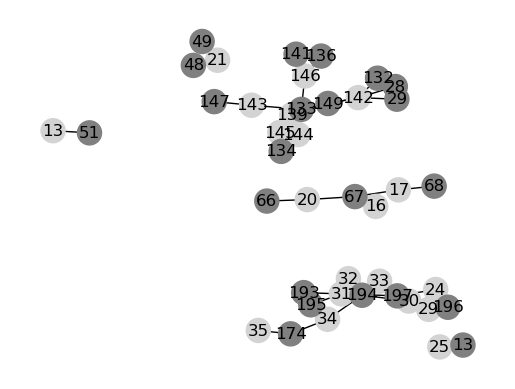

In [34]:
name = 'bz_0_cluster_1_12mer_bz_0_cluster_3_6mer_mg_adp' # No PAE less than 22 between contacting residues in this structure. 

filters = dict()
filters[f'not_{name}'] = contacts_df.name != name
filters['non_protein_contact'] = (contacts_df.gene_id_0 == 'none') | (contacts_df.gene_id_1 == 'none')
# filters['not_cluster_3'] = ~((contacts_df.gene_id_0 == 'bz_0_cluster_3') & (contacts_df.gene_id_1 == 'bz_0_cluster_3')) 
filters['same_protein_contact'] = (contacts_df.gene_id_0  == contacts_df.gene_id_1)
filters['low_contact_prob'] = contacts_df.contact_prob < 0.5

plot_contacts(apply_filters(filters, contacts_df))

apply_filters: 24712 entries removed by not_bz_0_cluster_1_6mer_bz_0_cluster_3_6mer_mg_adp.
apply_filters: 19020 entries removed by non_protein_contact.
apply_filters: 4570 entries removed by same_protein_contact.
apply_filters: 13104 entries removed by low_contact_prob.


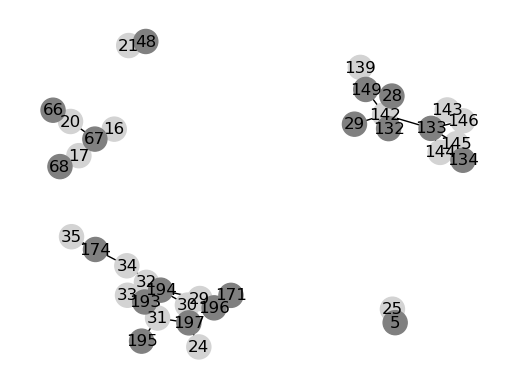

In [35]:
name = 'bz_0_cluster_1_6mer_bz_0_cluster_3_6mer_mg_adp' # No PAE less than 22 between contacting residues in this structure. 

filters = dict()
filters[f'not_{name}'] = contacts_df.name != name
filters['non_protein_contact'] = (contacts_df.gene_id_0 == 'none') | (contacts_df.gene_id_1 == 'none')
# filters['not_cluster_3'] = ~((contacts_df.gene_id_0 == 'bz_0_cluster_3') & (contacts_df.gene_id_1 == 'bz_0_cluster_3')) 
filters['same_protein_contact'] = (contacts_df.gene_id_0  == contacts_df.gene_id_1)
filters['low_contact_prob'] = contacts_df.contact_prob < 0.5

plot_contacts(apply_filters(filters, contacts_df))

apply_filters: 28128 entries removed by not_bz_0_cluster_1_1mer_bz_0_cluster_3_1mer_mg_adp.
apply_filters: 19020 entries removed by non_protein_contact.
apply_filters: 4570 entries removed by same_protein_contact.
apply_filters: 13104 entries removed by low_contact_prob.


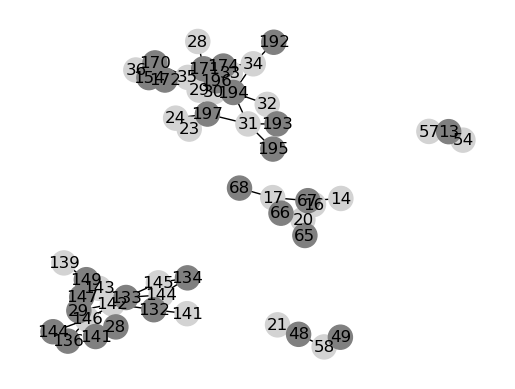

In [36]:
name = 'bz_0_cluster_1_1mer_bz_0_cluster_3_1mer_mg_adp' # No PAE less than 22 between contacting residues in this structure. 

filters = dict()
filters[f'not_{name}'] = contacts_df.name != name
filters['non_protein_contact'] = (contacts_df.gene_id_0 == 'none') | (contacts_df.gene_id_1 == 'none')
# filters['not_cluster_3'] = ~((contacts_df.gene_id_0 == 'bz_0_cluster_3') & (contacts_df.gene_id_1 == 'bz_0_cluster_3')) 
filters['same_protein_contact'] = (contacts_df.gene_id_0  == contacts_df.gene_id_1)
filters['low_contact_prob'] = contacts_df.contact_prob < 0.5

plot_contacts(apply_filters(filters, contacts_df))

In [23]:
msas = dict()
msas['cluster_1'] = MSAFile.from_file('../data/genes/cluster_1.afa')
msas['cluster_3'] = MSAFile.from_file('../data/genes/cluster_3.afa')




apply_filters: 14818 entries removed by non_atp_ligand.
apply_filters: 19020 entries removed by non_protein_contact.
apply_filters: 25820 entries removed by not_cluster_3.
apply_filters: 13104 entries removed by low_contact_prob.


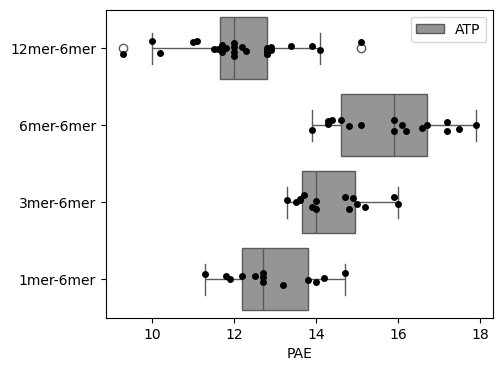

In [24]:
fig, ax = plt.subplots(figsize=(5, 4))

filters = dict()
filters['non_atp_ligand'] = ~(contacts_df.name.str.contains('atp'))
filters['non_protein_contact'] = (contacts_df.gene_id_0 == 'none') | (contacts_df.gene_id_1 == 'none') 
filters['not_cluster_3'] = ~((contacts_df.gene_id_0 == 'bz_0_cluster_3') & (contacts_df.gene_id_1 == 'bz_0_cluster_3')) 
filters['low_contact_prob'] = contacts_df.contact_prob < 0.5

metric = 'pae'

figure_df = apply_filters(filters, contacts_df).copy()

conditions = [figure_df.name.str.contains('mg_atp'), figure_df.name.str.contains('mg_adp')]
figure_df['ligand'] = np.select(conditions, ['ATP', 'ADP'], default='none')
figure_df = figure_df.sort_values('contact_prob', ascending=False).drop_duplicates(['edge_id', 'name'], keep='first')

sns.boxplot(figure_df, y='name', x=metric, hue='ligand', palette='Grays')
sns.stripplot(figure_df, y='name', x=metric, color='black')

labels = ['-'.join(re.findall(r'\d+mer', label.get_text())) for label in ax.get_yticklabels()]
ax.set_yticks(ax.get_yticks(), labels=labels)
ax.set_ylabel('')
ax.set_xlabel('PAE' if (metric == 'pae') else 'contact probability')

plt.show()

apply_filters: 14818 entries removed by non_atp_ligand.
apply_filters: 19020 entries removed by non_protein_contact.
apply_filters: 4570 entries removed by same_protein_contact.
apply_filters: 13104 entries removed by low_contact_prob.
apply_filters: 14818 entries removed by non_atp_ligand.
apply_filters: 19020 entries removed by non_protein_contact.
apply_filters: 4570 entries removed by same_protein_contact.
apply_filters: 13104 entries removed by low_contact_prob.


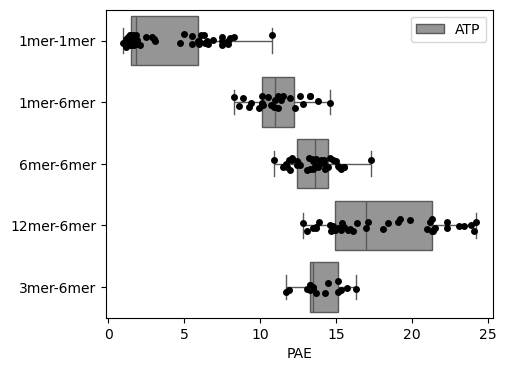

In [28]:
fig, ax = plt.subplots(figsize=(5, 4))

filters = dict()
filters['non_atp_ligand'] = ~(contacts_df.name.str.contains('atp'))
filters['non_protein_contact'] = (contacts_df.gene_id_0 == 'none') | (contacts_df.gene_id_1 == 'none') 
filters['same_protein_contact'] = (contacts_df.gene_id_0  == contacts_df.gene_id_1)
filters['low_contact_prob'] = contacts_df.contact_prob < 0.5

figure_df = apply_filters(filters, contacts_df).copy()

metric = 'pae'

figure_df = apply_filters(filters, contacts_df).copy()

conditions = [figure_df.name.str.contains('mg_atp'), figure_df.name.str.contains('mg_adp')]
figure_df['ligand'] = np.select(conditions, ['ATP', 'ADP'], default='none')
figure_df = figure_df.sort_values('contact_prob', ascending=False).drop_duplicates(['edge_id', 'name'], keep='first')

sns.boxplot(figure_df, y='name', x=metric, hue='ligand', palette='Grays')
sns.stripplot(figure_df, y='name', x=metric, color='black')

labels = ['-'.join(re.findall(r'\d+mer', label.get_text())) for label in ax.get_yticklabels()]
ax.set_yticks(ax.get_yticks(), labels=labels)
ax.set_ylabel('')
ax.set_xlabel('PAE' if (metric == 'pae') else 'contact probability')

plt.show()

In [26]:
# fig, axes = plt.subplots(ncols=2, figsize=(15, 4), sharey=False)

# keep = lambda name : (genome_id in name)

# for data_ in data.values():

#     if not keep(data_['name']):
#         continue 
#     name = data_['name'].replace(f'fold_{genome_id}_', '').replace(f'{genome_id}_', '')


#     n = data_['num_contacts']

#     # print(f'Maximum contact probability for {name}:', max(data_['contact_probs']))
#     print(f'Number of contacts for {name} with > 70% probability:', (np.array(data_['contact_probs']) > 0.7).sum())
#     if len(data_['pae']) < 2:
#         print(f'Skipping {name}, only one contact found.')
#         continue

#     sns.kdeplot(data_['pae'], label=f'{name} (n={n})', ax=axes[0])
#     sns.kdeplot(data_['contact_probs'], label=f'{name} (n={n})', ax=axes[1])

# axes[1].legend(bbox_to_anchor=(1.1, 0.6))

# axes[0].set_ylabel('density')
# axes[1].set_ylabel('density')

# axes[0].set_title('PAE')
# axes[1].set_title('contact probability')

# fig.tight_layout()
# plt.show()


In [27]:

# cluster_1_gene_id = CLUSTER_1_GENE_IDS[genome_id]
# cluster_3_gene_id = CLUSTER_3_GENE_IDS[genome_id]

# dssp_df = [DSSPFile.from_file(os.path.join(DSSP_OUTPUT_DIR, f'{cluster_1_gene_id}.dssp')).to_df().assign(cluster_id=1)]
# dssp_df += [DSSPFile.from_file(os.path.join(DSSP_OUTPUT_DIR, f'{cluster_3_gene_id}.dssp')).to_df().assign(cluster_id=3)]
# dssp_df = pd.concat(dssp_df).rename(columns={'residue':'idx', 'aa':'residue'}).drop(columns=['chain', 'code'])
# dssp_df['idx'] = dssp_df['idx'] - 1 # Need to shift the index to be zero-indexed. 

# figure_df = pd.DataFrame()

# for name in [f'fold_{genome_id}_cluster_1_6mer_{genome_id}_cluster_3_6mer_mg_atp', f'fold_{genome_id}_cluster_1_1mer_{genome_id}_cluster_3_1mer_mg_atp']:

#     contacts = dict()
#     contacts[1] = np.unique(data[name]['idxs_shifted'][0])
#     contacts[3] = np.unique(data[name]['idxs_shifted'][1])

#     for cluster_id, idxs in contacts.items():
#         for idx in idxs:
#             residue = CLUSTER_1_SEQS[genome_id][idx] if (cluster_id == 1) else CLUSTER_3_SEQS[genome_id][idx]
#             figure_df.loc[f'{residue}{idx}', name] = True
#             figure_df.loc[f'{residue}{idx}', 'idx'] = idx
#             figure_df.loc[f'{residue}{idx}', 'residue'] = residue
#             figure_df.loc[f'{residue}{idx}', 'cluster_id'] = cluster_id

# figure_df = figure_df.fillna(False)
# index = figure_df.index.copy()
# figure_df = figure_df.merge(dssp_df, on=['cluster_id', 'idx', 'residue'], how='left')
# figure_df.index = index

# fig, axes = plt.subplots(ncols=2, figsize=(6, 8))

# label_map = dict()
# label_map[f'fold_{genome_id}_cluster_1_6mer_{genome_id}_cluster_3_6mer_mg_atp'] = '6-mer complex'
# label_map[f'fold_{genome_id}_cluster_1_1mer_{genome_id}_cluster_3_1mer_mg_atp'] = '1-mer complex'

# for ax, (cluster_id, df) in zip(axes, figure_df.groupby('cluster_id')):
#     sns.heatmap(df[list(label_map.keys())].astype(int), ax=ax, cbar=False, cmap='binary')
#     ax.set_title(f'cluster {int(cluster_id)}')
#     ax.twinx().set_yticks(ax.get_yticks(), labels=df.structure.values[::-1])
#     ax.set_xticks(ax.get_xticks(), labels=[label_map.get(label.get_text()) for label in ax.get_xticklabels()])

# fig.tight_layout()
# plt.show()